In [2]:
"""
Full-band CFR demo – Python 3.11 · TF 2.19 · Sionna 1.0.2
"""

# --------------------------------------------------------------------#
# 0) Imports & GPU housekeeping
# --------------------------------------------------------------------#
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

try:
    import sionna, sionna.rt
except ImportError:
    os.system("pip install -q --upgrade sionna")
    import sionna, sionna.rt

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, subcarrier_frequencies

# Other imports          
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import sys
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, watt_to_dbm

from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector
from sionna.phy.mimo import StreamManagement

# Import Sionna RT components
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver
import random


2025-04-26 09:50:50.293482: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 09:50:50.315023: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-26 09:50:50.315040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-26 09:50:50.315804: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-26 09:50:50.319714: I tensorflow/core/platform/cpu_feature_guar

In [3]:
"""
Full-band CFR demo – Python 3.11 · TF 2.19 · Sionna 1.0.2
"""

# ── 參數區 ───────────────────────────────────────────────────────────────
# 場景與天線
SCENE_NAME      = sionna.rt.scene.etoile
TX_ARRAY_CONFIG = dict(num_rows=1, num_cols=1,
                       vertical_spacing=0.5, horizontal_spacing=0.5,
                       pattern="iso", polarization="V")
RX_ARRAY_CONFIG = TX_ARRAY_CONFIG

# 發射機設定： (name, position, orientation, role)

# (name, pos, ori, role, power_dbm)
TX_LIST = [
  ("tx0",  [-100,-100,20], [np.pi*5/6,0,0],     "desired", 40),
  ("tx1",  [-100,  50,20], [np.pi/6,  0,0],     "desired", 40),
  ("tx2",  [ 100,-100,20], [-np.pi/2,0,0],      "desired", 30),
  ("jam1", [ 100,  50,20], [np.pi/2,  0,0],     "jammer",  40),
  ("jam2", [  50, 100,20], [np.pi/3,  0,0],     "jammer",  50),
  ("jam3", [ -50, -50,20], [-np.pi/3,0,0],      "jammer",  30),
 
]



RX_CONFIG      = ("rx", [0,0,50])  # (name, position)

# PathSolver 參數
PATHSOLVER_ARGS = dict(max_depth=6,
                       los=True,
                       specular_reflection=True,
                       diffuse_reflection=False,
                       refraction=True,
                       synthetic_array=False,
                       seed=41)

# RadioMapSolver 參數
RMSOLVER_ARGS   = dict(max_depth=5,
                       cell_size=(1.,1.),
                       samples_per_tx=10**7)

# OFDM / QPSK 參數
N_SYMBOLS       = 1
N_SUBCARRIERS   = 1024
SUBCARRIER_SPACING = 30e3  # Hz


# 通道品質參數
JNR_dB          = 5.0
EBN0_dB         = 20.0

# 繪圖範圍（SINR dB）
SINR_VMIN       = -40
SINR_VMAX       =   0


(6, 1024)
(1024,) (1024,)


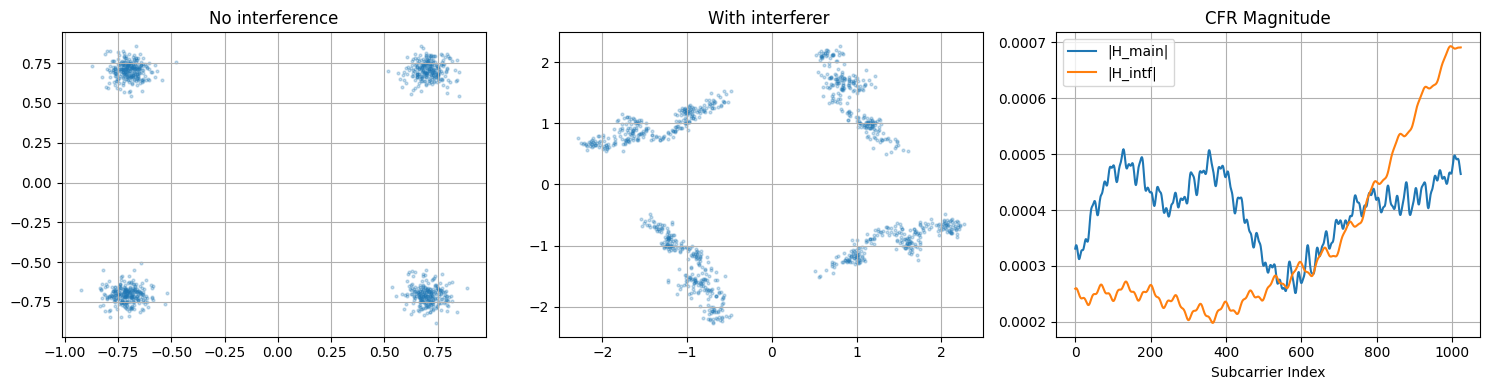

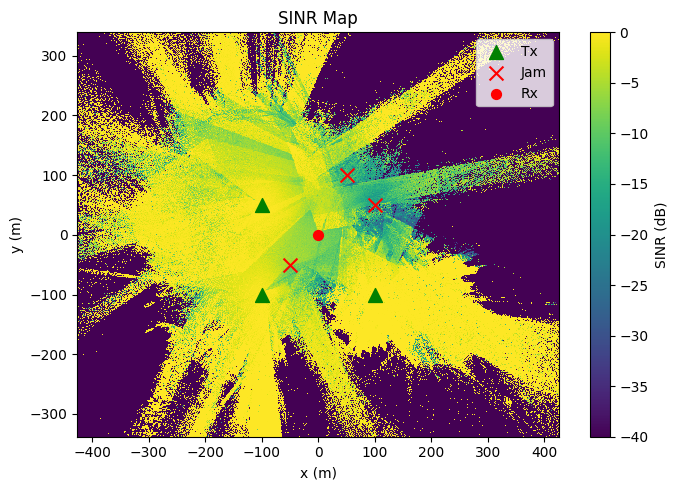

In [4]:

# ── 程式區 ───────────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sionna, sionna.rt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, RadioMapSolver, subcarrier_frequencies)

# GPU 設定
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
gpus = tf.config.list_physical_devices("GPU")
if gpus: tf.config.experimental.set_memory_growth(gpus[0], True)

# 1) 建立場景與天線配置
scene = load_scene(SCENE_NAME)
scene.tx_array = PlanarArray(**TX_ARRAY_CONFIG)
scene.rx_array = PlanarArray(**RX_ARRAY_CONFIG)
for tx_name in scene.transmitters.copy():  
    scene.remove(tx_name)
# 再把所有 receiver name 拿出來，一個個 remove
for rx_name in scene.receivers.copy():
    scene.remove(rx_name)

# 確認都清空了
assert len(scene.transmitters)==0 and len(scene.receivers)==0

# 2) 新增 Tx (含 role 標籤)
def add_tx(scene, name, pos, ori, role, power_dbm):
    tx = Transmitter(name=name, position=pos,
                     orientation=ori, power_dbm=power_dbm)
    tx.role = role
    scene.add(tx)
    return tx

# 迴圈時 unpack 五個欄位
for name, pos, ori, role, p_dbm in TX_LIST:
    add_tx(scene, name, pos, ori, role, p_dbm)


# 3) 新增 Rx
rx_name, rx_pos = RX_CONFIG
rx = Receiver(name=rx_name, position=rx_pos)
scene.add(rx)

# 4) 自動分組 indices
tx_names = scene.transmitters
all_txs   = [scene.get(n) for n in tx_names]
idx_des   = [i for i,tx in enumerate(all_txs) if getattr(tx,'role',None)=='desired']
idx_jam   = [i for i,tx in enumerate(all_txs) if getattr(tx,'role',None)=='jammer']

# 5) RadioMap 計算
rm_solver = RadioMapSolver()
rm = rm_solver(scene, **RMSOLVER_ARGS)

# 6) PathSolver 函式
solver = PathSolver()
def solve():
    return solver(scene, **PATHSOLVER_ARGS)

# 7) 計算 CFR
freqs = subcarrier_frequencies(N_SUBCARRIERS, SUBCARRIER_SPACING)
paths = solve()

def dbm2w(dbm):
    return 10**(dbm/10) / 1000

tx_powers = [ dbm2w(scene.get(n).power_dbm) 
              for n in scene.transmitters ]

H     = paths.cfr(frequencies=freqs,
                   normalize=False,
                   normalize_delays=True,
                   out_type="numpy").squeeze()
print(H.shape)



# h_main = np.sum(H[idx_des, :], axis=0)
# h_intf = np.sum(H[idx_jam, :], axis=0)

h_main = sum( np.sqrt(tx_powers[i]) * H[i] 
              for i in idx_des )
h_intf = sum( np.sqrt(tx_powers[i]) * H[i] 
              for i in idx_jam )
print(h_main.shape, h_intf.shape)


# 8) 產生 QPSK+OFDM 符號
bits       = np.random.randint(0,2,(N_SYMBOLS, N_SUBCARRIERS, 2))

X_qpsk     = (1-2*bits[...,0] + 1j*(1-2*bits[...,1]))/np.sqrt(2)

Y_sig      = X_qpsk * h_main[np.newaxis,:]
Y_int      = X_qpsk * h_intf[np.newaxis,:]
p_sig      = np.mean(np.abs(Y_sig)**2)
p_int      = np.mean(np.abs(Y_int)**2)
# scale      = np.sqrt(p_sig/p_int/10**(JNR_dB/10)) if p_int>0 else 0
# Y_int     *= scale
N0         = p_sig/(10**(EBN0_dB/10)*2)
noise      = np.sqrt(N0/2)*(np.random.randn(*Y_sig.shape)+1j*np.random.randn(*Y_sig.shape))
Y_tot      = Y_sig + Y_int + noise
y_eq_no_i  = (Y_sig + noise)   / h_main
y_eq_with_i= (Y_sig + Y_int + noise) / h_main

# # 展平所有点，拿到 real & imag
# x0 = y_eq_no_i[0, :] .real
# y0 = y_eq_no_i[0, :] .imag
# x1 = y_eq_with_i[0, :].real
# y1 = y_eq_with_i[0, :].imag

# # 计算全局最小/最大
# xmin, xmax = np.min([x0.min(), x1.min()]), np.max([x0.max(), x1.max()])
# ymin, ymax = np.min([y0.min(), y1.min()]), np.max([y0.max(), y1.max()])

# # 加一点 margin
# margin_x = 0.1*(xmax-xmin)
# margin_y = 0.1*(ymax-ymin)
# xmin, xmax = xmin-margin_x, xmax+margin_x
# ymin, ymax = ymin-margin_y, ymax+margin_y

# 9) 繪製星座 & CFR
fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].scatter(y_eq_no_i.real, y_eq_no_i.imag, s=4, alpha=.25)
ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference"); ax[0].grid(True)
ax[1].set(title="With interferer "); ax[1].grid(True)
ax[2].plot(np.abs(h_main), label="|H_main|")
ax[2].plot(np.abs(h_intf), label="|H_intf|")
ax[2].set(title="CFR Magnitude", xlabel="Subcarrier Index"); ax[2].legend(); ax[2].grid(True)
plt.tight_layout(); plt.show()

# 10) 計算並繪製 SINR Map
cc        = rm.cell_centers.numpy()
x_unique  = cc[0,:,0]; y_unique = cc[:,0,1]
rss_list  = [rm.rss[i].numpy() for i in range(len(all_txs))]
N0_map    = 1e-12
rss_des   = sum(rss_list[i] for i in idx_des)
rss_jam   = sum(rss_list[i] for i in idx_jam)
sinr_db   = 10*np.log10(np.clip(rss_des/(rss_des+rss_jam+N0_map),1e-12,None))

X,Y = np.meshgrid(x_unique,y_unique)
plt.figure(figsize=(7,5))
pcm = plt.pcolormesh(X, Y, sinr_db, shading='nearest',
                     vmin=SINR_VMIN, vmax=SINR_VMAX)
plt.colorbar(pcm, label="SINR (dB)")
plt.scatter([t.position[0] for t in all_txs if t.role=='desired'],
            [t.position[1] for t in all_txs if t.role=='desired'],
            c='g', marker='^', s=100, label='Tx')
plt.scatter([t.position[0] for t in all_txs if t.role=='jammer'],
            [t.position[1] for t in all_txs if t.role=='jammer'],
            c='red', marker='x', s=100, label='Jam')
plt.scatter(rx.position[0], rx.position[1],
            c='red', marker='o', s=50, label='Rx')
plt.legend(); plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.title("SINR Map"); plt.tight_layout(); plt.show()


In [5]:
# 1) 获取单元格中心的 x 和 y 坐标
cc       = rm.cell_centers.numpy()    # shape (Ny, Nx, 3)
print(cc.shape)                  # (480, 320, 3)
x_unique = cc[0, :, 0]                # 第一行所有格子中心的 x
y_unique = cc[:, 0, 1]                # 第一列所有格子中心的 y

# 2) 提取前五颗发射机的rss 并转换为 NumPy
rss_list = [rm.rss[i].numpy() for i in range(5)]  # tx0, tx1, tx2
N0 = 1e-12  # 你可以根据实际情况调整

# 3) 计算合并后的 SINR
# rss_list 中分别对应 [tx0, tx1, tx2, jam1, jam2]
# rss_desired = rss_list[0] + rss_list[1] + rss_list[2]       # tx0+tx1+tx2 的总接收功率
# rss_jammer  = rss_list[3] + rss_list[4]                     # jam1+jam2 的总接收功率

# ⇒ Radio-map RSS
rss_desired = sum(rss_list[i] for i in idx_des)

print(rss_list)
print(idx_jam)
rss_jammer  = sum(rss_list[i] for i in idx_jam)


# SINR = desired / (desired + interferers + noise)
sinr = rss_desired / (rss_desired + rss_jammer + N0)

# 如果你想看 dB 形式：
sinr_db = 10 * np.log10(np.clip(sinr, 1e-12, None))


# 4) 绘图
X, Y = np.meshgrid(x_unique, y_unique)
plt.figure(figsize=(7,5))
pcm = plt.pcolormesh(
    X, Y, sinr_db,
    shading='nearest',
    vmin=-40, vmax=0
)
plt.colorbar(pcm, label="SINR (dB)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("SINR Map: tx0+tx1+tx2 vs jam1+jam2")
# ⇒ 繪圖（自動帶位置）
plt.scatter([t.position[0] for t in all_txs if t.role=='desired'],
            [t.position[1] for t in all_txs if t.role=='desired'],
            c='g', marker='^', s=100, label='Tx')

plt.scatter([t.position[0] for t in all_txs if t.role=='jammer'],
            [t.position[1] for t in all_txs if t.role=='jammer'],
            c='red', marker='x', s=100, label='Jam')
plt.scatter(rx.position[0],
            rx.position[1],
            c='r', marker='o', s=50, label='Rx')
plt.legend()
plt.tight_layout()
plt.show()


(677, 854, 3)
[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 

IndexError: list index out of range